## Optymalizacja parametrów obróbki

1. Konfiguracja

In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

2. Definicja funkcji

In [11]:
def optimize_machining_parameters(filepath='/content/dane_obrobka_cnc_po_anomaliach.csv'):
    print("--- ETAP 5: OPTYMALIZACJA PARAMETRÓW OBRÓBKI ---")
    df = pd.read_csv(filepath)

    # Do planowania procesu przed obróbką nie są znane wartości wibracji ani temperatur.
    # Znane jest tylko to, co jest wpisywane do programu maszyny + twardość z atestu.
    features = ['Predkosc_Skrawania_vc', 'Posuw_f', 'Glebokosc_Skrawania_ap',
                'Twardosc_Odlewu_HB', 'Zuzycie_Narzedzia_VB']

    X_tech = df[features]
    y_tech = df['Chropowatosc_Ra']

    print("Trenowanie modelu technologicznego XGBoost...")
    reg_tech = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
    reg_tech.fit(X_tech, y_tech)

    print("Generowanie wirtualnych scenariuszy obróbki...")
    vc_range = np.linspace(350, 450, 10)    # Prędkość skrawania [m/min]
    f_range = np.linspace(0.05, 0.25, 20)   # Posuw [mm/obr]
    ap_range = np.linspace(1.0, 3.0, 10)    # Głębokość [mm]

    # Tworzenie siatki wszystkich kombinacji
    grid = np.array(np.meshgrid(vc_range, f_range, ap_range)).T.reshape(-1, 3)
    df_grid = pd.DataFrame(grid, columns=['Predkosc_Skrawania_vc', 'Posuw_f', 'Glebokosc_Skrawania_ap'])

    # Konkretny materiał (np. HB=90) i nowe narzędzie (VB=0.0)
    df_grid['Twardosc_Odlewu_HB'] = 90.0
    df_grid['Zuzycie_Narzedzia_VB'] = 0.0

    # WIRTUALNA SYMULACJA OBRÓBKI
    print("Wnioskowanie (Predykcja) dla tysięcy wariantów...")
    df_grid['Przewidywane_Ra'] = reg_tech.predict(df_grid[features])

    # Obliczanie Wydajności Skrawania (MRR - Material Removal Rate) w [cm^3/min]
    # Wzór: vc * f * ap
    df_grid['MRR'] = df_grid['Predkosc_Skrawania_vc'] * df_grid['Posuw_f'] * df_grid['Glebokosc_Skrawania_ap']

    # OPTYMALIZACJA (Filtrowanie i sortowanie)
    limit_ra = 1.6
    df_valid = df_grid[df_grid['Przewidywane_Ra'] <= limit_ra].copy()

    if df_valid.empty:
        print(f"\n[!] UWAGA: Fizyka procesu nie pozwala na osiągnięcie Ra <= {limit_ra} µm.")
        limit_ra = 3.2  # Rozluźnienie kryterium do granicy klasy "Do_Poprawy"
        print(f"[!] Algorytm rozluźnia restrykcje. Szukam optymalizacji dla Ra <= {limit_ra} µm...")
        df_valid = df_grid[df_grid['Przewidywane_Ra'] <= limit_ra].copy()

        if df_valid.empty:
            best_possible_ra = df_grid['Przewidywane_Ra'].min()
            limit_ra = best_possible_ra + 0.1
            print(f"[!] Krytyczny brak rozwiązań! Optymalizuję dla absolutnego minimum Ra na maszynie: ~{limit_ra:.2f} µm")
            df_valid = df_grid[df_grid['Przewidywane_Ra'] <= limit_ra].copy()

    # Szukanie parametru z największą wydajnością w dopuszczalnym zbiorze
    best_params = df_valid.sort_values(by='MRR', ascending=False).iloc[0]

    print("\n==================================================")
    print("🚀 ZNALEZIONO OPTYMALNE PARAMETRY (Dla Twardości HB=90, Nowe Narzędzie)")
    print("==================================================")
    print(f"Prędkość skrawania (vc): {best_params['Predkosc_Skrawania_vc']:.0f} m/min")
    print(f"Posuw (f):               {best_params['Posuw_f']:.3f} mm/obr")
    print(f"Głębokość skrawania (ap):{best_params['Glebokosc_Skrawania_ap']:.1f} mm")
    print("-" * 50)
    print(f"Przewidywane Ra:         {best_params['Przewidywane_Ra']:.3f} µm (Obecny limit: {limit_ra:.2f})")
    print(f"Wydajność MRR:           {best_params['MRR']:.1f} (Jedn. objętościowych)")
    print("==================================================\n")

    # WIZUALIZACJA PRZESTRZENI DECYZYJNEJ
    plt.figure(figsize=(10, 6))

    sns.scatterplot(data=df_grid, x='MRR', y='Przewidywane_Ra', alpha=0.3, color='gray', label='Wszystkie scenariusze')
    sns.scatterplot(data=df_valid, x='MRR', y='Przewidywane_Ra', alpha=0.6, color='green', label=f'Dopuszczalne (Ra <= {limit_ra:.2f})')

    plt.scatter(best_params['MRR'], best_params['Przewidywane_Ra'], color='red', s=150, marker='*', edgecolor='black', label='Optimum (Max MRR)')
    plt.axhline(limit_ra, color='red', linestyle='--', label=f'Obecna granica (Ra={limit_ra:.2f})')

    plt.title('Przestrzeń Optymalizacji Parametrów Technologicznych', fontsize=14, pad=15)
    plt.xlabel('Wydajność Skrawania (MRR)', fontweight='bold')
    plt.ylabel('Przewidywana Chropowatość Ra [µm]', fontweight='bold')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig('optymalizacja_parametrow.png', bbox_inches='tight')
    plt.show()
    print("Wykres zapisany jako 'optymalizacja_parametrow.png'.")

3. Uruchomienie

--- ETAP 5: OPTYMALIZACJA PARAMETRÓW OBRÓBKI ---
Trenowanie modelu technologicznego XGBoost...
Generowanie wirtualnych scenariuszy obróbki...
Wnioskowanie (Predykcja) dla tysięcy wariantów...

🚀 ZNALEZIONO OPTYMALNE PARAMETRY (Dla Twardości HB=90, Nowe Narzędzie)
Prędkość skrawania (vc): 450 m/min
Posuw (f):               0.092 mm/obr
Głębokość skrawania (ap):3.0 mm
--------------------------------------------------
Przewidywane Ra:         1.524 µm (Obecny limit: 1.60)
Wydajność MRR:           124.3 (Jedn. objętościowych)



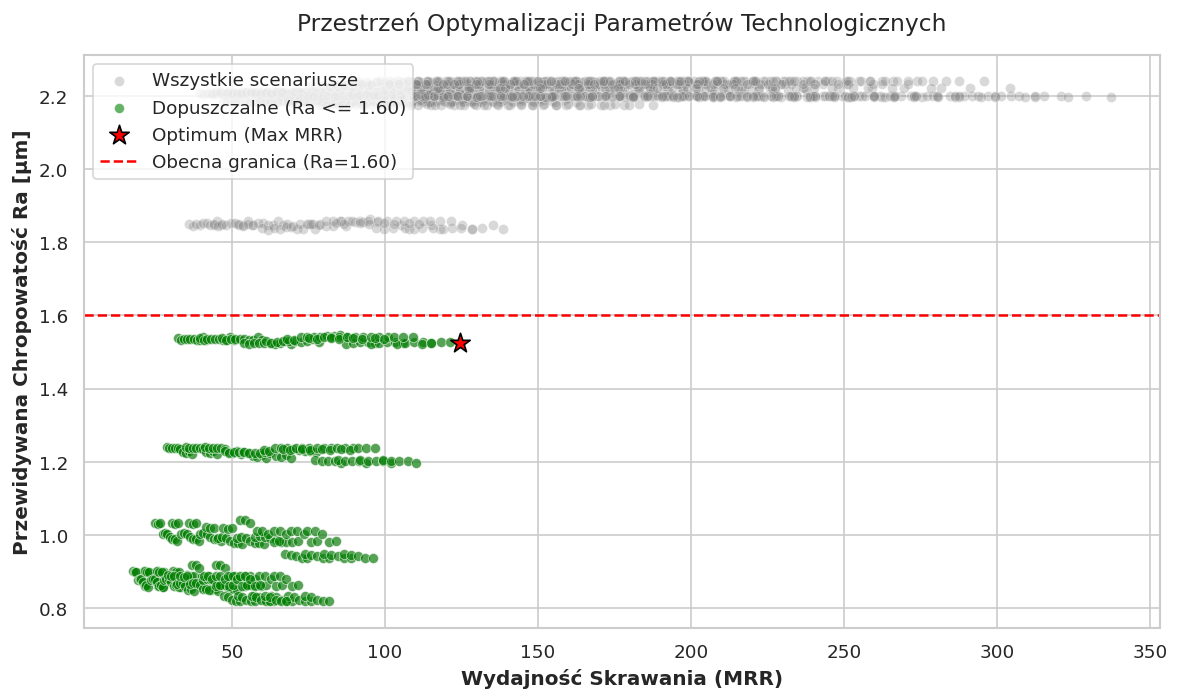

Wykres zapisany jako 'optymalizacja_parametrow.png'.


In [12]:
optimize_machining_parameters()